<a href="https://colab.research.google.com/github/ajaynice1996/DIY_MRI_Workshop_II_Recon/blob/main/Day_3_final_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Zero-Shot Noise2Noise: Efficient Image Denoising without any Data**


This repository provides a demonstration of how to use our proposed ZS-N2N (Zero-Shot Noise2Noise) algorithm to denoise images without any training data or a noise model or level as input. The notebook is Pytorch based.

The method is as simple as convolving the noisy image with two fixed kernels to create a pair of downsampled images. A simple 2 layer CNN is then trained with a consistency loss to map one downsampled image to the other.

The notebook can easily be run on GPU or CPU. Choose the device to be 'cuda' if you want to run on GPU, otherwise choose 'cpu'. If you choose 'cuda' remember to change your colab runtime to GPU via 'Runtime' -> 'Change runtime type'.



It is recommended to normalize the pixel range of the images to 0-1, as this is the range the hyperparameters and initialization of the network were tested with.

The network's size was optimized for images of size 256x256. If you have smaller or larger images, you might want to decrease or increase the network's size. This can be done by changing the variable "chan_embed".

The 20 test images from SIDD and PolyU can be found here: https://drive.google.com/file/d/1oJ2wIMPAxK353Shz5kW0Xg-KXmwUwYZR/ .
They are normalized and converted to Pytorch tensors, and can be loaded with torch.load('file_name').

In [1]:
from google.colab import drive
drive.mount('/drive')

Mounted at /drive


In [2]:
!git clone https://github.com/ajaynice1996/DIY_MRI_Workshop_II_Recon

Cloning into 'DIY_MRI_Workshop_II_Recon'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 174 (delta 28), reused 7 (delta 1), pack-reused 109 (from 2)
Receiving objects: 100% (174/174), 112.42 MiB | 18.48 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [3]:
#Enter device here, 'cuda' for GPU, and 'cpu' for CPU
device = 'cuda'

In [4]:
!pip install nilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.3
    Uninstalling pandas-2.2.3:
      Successfully uninstalled pandas-2.2.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
cud

In [5]:
!pip install colorama
!pip -q install roipoly

  Preparing metadata (setup.py) ... done


In [6]:
import sys
print(f"Python Version: {sys.version}")

import subprocess
# List installed packages using pip
print("\nInstalled Python Packages:\n")
subprocess.run([sys.executable, '-m', 'pip', 'freeze'])

Python Version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]

Installed Python Packages:



CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'freeze'], returncode=0)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

Successfully loaded POCEMR003_T2.nii.gz
Image dimensions (voxels): (224, 224, 160)
Voxel dimensions (resolution in mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))

Min value of numpy slice (before tensor conversion): 0.0000
Max value of numpy slice (before tensor conversion): 255.0000
Note: Normalizing numpy slice to 0-1 range for tensor conversion.
Shape of the prepared clean_img (torch tensor - B C H W): torch.Size([1, 1, 224, 224])
Min value of clean_img (torch tensor): 0.0000
Max value of clean_img (torch tensor): 1.0000


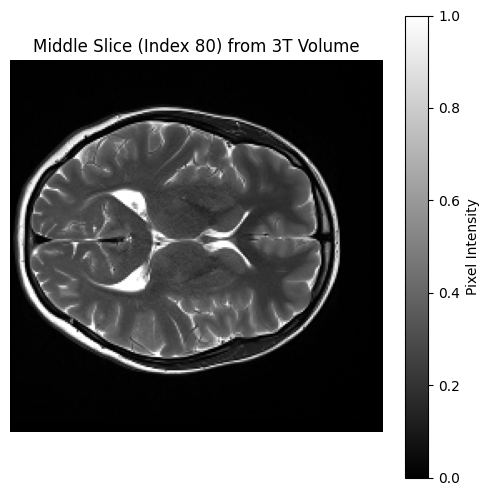


Successfully loaded POCEMR003_T2.nii.gz from 64mT folder for noisy_img
Image dimensions (voxels) for 64mT noisy_img: (224, 224, 160)
Voxel dimensions (resolution in mm) for 64mT noisy_img: (np.float32(1.0), np.float32(1.0), np.float32(1.0))

Min value of noisy numpy slice (before tensor conversion): 0.0000
Max value of noisy numpy slice (before tensor conversion): 255.0000
Note: Normalizing noisy numpy slice to 0-1 range for tensor conversion.
Shape of the prepared noisy_img (torch tensor - B C H W): torch.Size([1, 1, 224, 224])
Min value of noisy_img (torch tensor): 0.0000
Max value of noisy_img (torch tensor): 1.0000


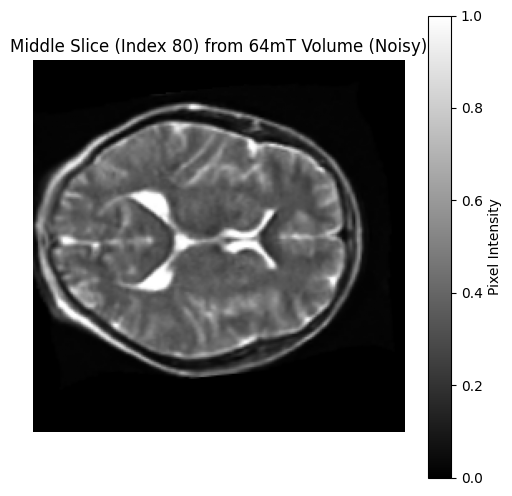

In [150]:
import nibabel as nib
import os
# Define the base path to the folder in Google Drive
base_path = '/content/DIY_MRI_Workshop_II_Recon/data/Training_data/POCEMR003/3T'

# Assuming the t2w image is named 't2w_image.nii.gz' as a common convention.
# If the exact filename is different, please update 'image_filename'.
image_filename = 'POCEMR003_T2.nii.gz'

# Construct the full path to the image file
image_path = os.path.join(base_path, image_filename)

# Load the NIfTI image and extract information
try:
    nifti_img = nib.load(image_path)
    clean_volume = nifti_img.get_fdata()
    header = nifti_img.header
    voxel_dims = header.get_zooms()

    print(f"Successfully loaded {image_filename}")
    print(f"Image dimensions (voxels): {clean_volume.shape}")
    print(f"Voxel dimensions (resolution in mm): {voxel_dims}")
    # You can uncomment these lines to print more header info if needed
    # print(f"Data type: {header.get_data_dtype()}")
    # print(f"Affine transformation:\n{nifti_img.affine}")

    # Extract a middle slice from the 3D volume
    slice_index = clean_volume.shape[2] // 2
    clean_img_np_slice = clean_volume[:, :, slice_index]

    print(f"\nMin value of numpy slice (before tensor conversion): {clean_img_np_slice.min():.4f}")
    print(f"Max value of numpy slice (before tensor conversion): {clean_img_np_slice.max():.4f}")

    # Normalize the slice to 0-1 range for tensor conversion if its not already
    if clean_img_np_slice.max() > 1.0 or clean_img_np_slice.min() < 0.0:
        print("Note: Normalizing numpy slice to 0-1 range for tensor conversion.")
        clean_img_np_slice = (clean_img_np_slice - clean_img_np_slice.min()) / (clean_img_np_slice.max() - clean_img_np_slice.min())

    # Convert the numpy array slice to a PyTorch tensor
    # Add a channel dimension (C=1 for grayscale) and a batch dimension (B=1)
    # This will be the 'clean_img' used by the rest of the notebook
    clean_img = torch.from_numpy(clean_img_np_slice).float().unsqueeze(0).unsqueeze(0)

    print(f"Shape of the prepared clean_img (torch tensor - B C H W): {clean_img.shape}")
    print(f"Min value of clean_img (torch tensor): {clean_img.min():.4f}")
    print(f"Max value of clean_img (torch tensor): {clean_img.max():.4f}")

    # Display the middle slice as a grayscale image
    plt.figure(figsize=(6, 6))
    plt.imshow(clean_img_np_slice, cmap='gray')
    plt.title(f'Middle Slice (Index {slice_index}) from 3T Volume')
    plt.colorbar(label='Pixel Intensity')
    plt.axis('off') # Hide axes ticks for cleaner display
    plt.show()

except FileNotFoundError:
    print(f"Error: The file {image_path} was not found. Please check the path and filename.")
except Exception as e:
    print(f"An error occurred while loading or processing the image: {e}")

# --- Code for 64mT folder and noisy_img ---

# Define the base path to the 64mT folder in Google Drive
base_path_64mT = '/content/DIY_MRI_Workshop_II_Recon/data/Training_data/POCEMR003/64mT'

# Assuming the t2w image is named 't2w_image.nii.gz' as a common convention.
# If the exact filename is different, please update 'image_filename_64mT'.
image_filename_64mT = 'POCEMR003_T2.nii.gz'

# Construct the full path to the image file
image_path_64mT = os.path.join(base_path_64mT, image_filename_64mT)

# Load the NIfTI image and extract information for noisy_img
try:
    nifti_img_64mT_noisy = nib.load(image_path_64mT)
    noisy_volume = nifti_img_64mT_noisy.get_fdata()
    header_64mT_noisy = nifti_img_64mT_noisy.header
    voxel_dims_64mT_noisy = header_64mT_noisy.get_zooms()

    print(f"\nSuccessfully loaded {image_filename_64mT} from 64mT folder for noisy_img")
    print(f"Image dimensions (voxels) for 64mT noisy_img: {noisy_volume.shape}")
    print(f"Voxel dimensions (resolution in mm) for 64mT noisy_img: {voxel_dims_64mT_noisy}")

    # Extract a middle slice from the 3D volume
    slice_index_noisy = noisy_volume.shape[2] // 2
    noisy_img_np_slice = noisy_volume[:, :, slice_index_noisy]

    print(f"\nMin value of noisy numpy slice (before tensor conversion): {noisy_img_np_slice.min():.4f}")
    print(f"Max value of noisy numpy slice (before tensor conversion): {noisy_img_np_slice.max():.4f}")

    # Normalize the slice to 0-1 range for tensor conversion if its not already
    if noisy_img_np_slice.max() > 1.0 or noisy_img_np_slice.min() < 0.0:
        print("Note: Normalizing noisy numpy slice to 0-1 range for tensor conversion.")
        noisy_img_np_slice = (noisy_img_np_slice - noisy_img_np_slice.min()) / (noisy_img_np_slice.max() - noisy_img_np_slice.min())

    # Convert the numpy array slice to a PyTorch tensor
    # Add a channel dimension (C=1 for grayscale) and a batch dimension (B=1)
    noisy_img = torch.from_numpy(noisy_img_np_slice).float().unsqueeze(0).unsqueeze(0)

    print(f"Shape of the prepared noisy_img (torch tensor - B C H W): {noisy_img.shape}")
    print(f"Min value of noisy_img (torch tensor): {noisy_img.min():.4f}")
    print(f"Max value of noisy_img (torch tensor): {noisy_img.max():.4f}")

    # Display the middle slice as a grayscale image
    plt.figure(figsize=(6, 6))
    plt.imshow(noisy_img_np_slice, cmap='gray')
    plt.title(f'Middle Slice (Index {slice_index_noisy}) from 64mT Volume (Noisy)')
    plt.colorbar(label='Pixel Intensity')
    plt.axis('off') # Hide axes ticks for cleaner display
    plt.show()

except FileNotFoundError:
    print(f"Error: The file {image_path_64mT} was not found. Please check the path and filename.")
except Exception as e:
    print(f"An error occurred while loading or processing the 64mT image for noisy_img: {e}")

Add noise to the image

In [151]:
noise_type = 'gauss' # Either 'gauss' or 'poiss'
noise_level = 50     # Pixel range is 0-255 for Gaussian, and 0-1 for Poission

def add_noise(x,noise_level):

    if noise_type == 'gauss':
        noisy = x + torch.normal(0, noise_level/255, x.shape)
        noisy = torch.clamp(noisy,0,1)

    elif noise_type == 'poiss':
        noisy = torch.poisson(noise_level * x)/noise_level

    return noisy

noisy_img = add_noise(noisy_img, noise_level)

In [152]:
clean_img = clean_img.to(device)
noisy_img = noisy_img.to(device)

We next define our network, which is a 2 layer CNN

In [153]:
class network(nn.Module):
    def __init__(self,n_chan,chan_embed=48):
        super(network, self).__init__()

        self.act = nn.LeakyReLU(negative_slope=0.2, inplace=True)
        self.conv1 = nn.Conv2d(n_chan,chan_embed,3,padding=1)
        self.conv2 = nn.Conv2d(chan_embed, chan_embed, 3, padding = 1)
        self.conv3 = nn.Conv2d(chan_embed, n_chan, 1)

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.conv3(x)

        return x

n_chan = clean_img.shape[1]
model = network(n_chan)
model = model.to(device)
print("The number of parameters of the network is: ",  sum(p.numel() for p in model.parameters() if p.requires_grad))

The number of parameters of the network is:  21313


We next introduce the image pair downsampler which outputs two downsampled images of half the spatial resolution by averaging diagonal pixels in non-overlapping patches, as shown in the below figure.

It is realised by convolving the image with the 2 fixed kernels: $k_1 = \begin{bmatrix}0 & 0.5 \\0.5 & 0\end{bmatrix}$ and $k_2 = \begin{bmatrix}0.5 & 0 \\0 & 0.5\end{bmatrix}$, where the convolution has stride=2, and is applied to each image channel separately.

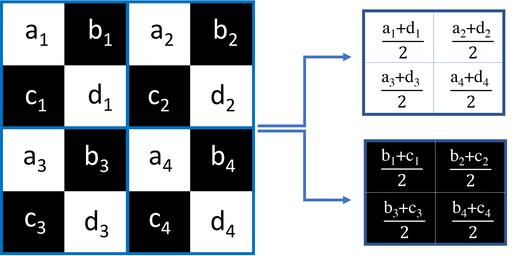

In [154]:
def pair_downsampler(img):
    #img has shape B C H W
    c = img.shape[1]

    filter1 = torch.FloatTensor([[[[0 ,0.5],[0.5, 0]]]]).to(img.device)
    filter1 = filter1.repeat(c,1, 1, 1)

    filter2 = torch.FloatTensor([[[[0.5 ,0],[0, 0.5]]]]).to(img.device)
    filter2 = filter2.repeat(c,1, 1, 1)

    output1 = F.conv2d(img, filter1, stride=2, groups=c)
    output2 = F.conv2d(img, filter2, stride=2, groups=c)

    return output1, output2

Display noisy image and its corresponding downsampled pair. Note how the downsampled images have half the spatial resolution.

Text(0.5, 1.0, 'Second downsampled')

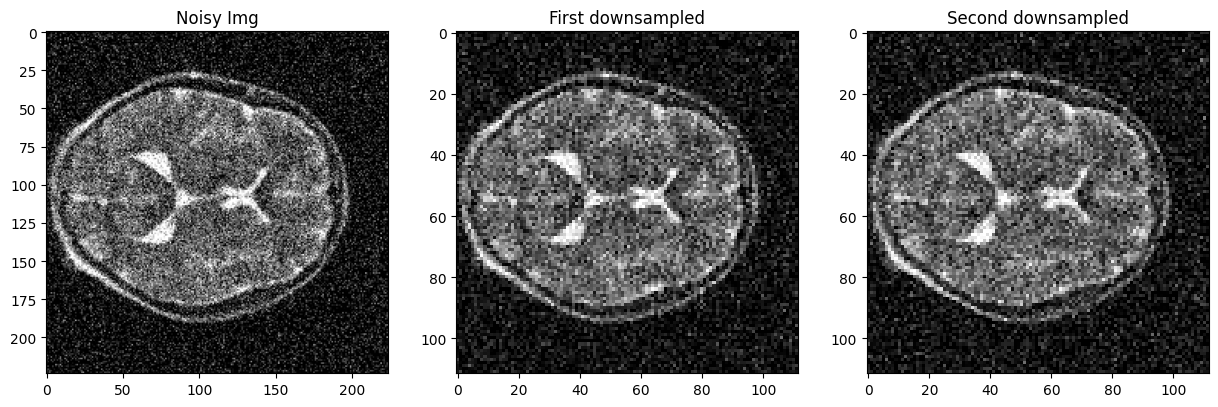

In [155]:
img1, img2 = pair_downsampler(noisy_img)

img0 = noisy_img.cpu().squeeze(0).permute(1,2,0)
img1 = img1.cpu().squeeze(0).permute(1,2,0)
img2 = img2.cpu().squeeze(0).permute(1,2,0)

fig, ax = plt.subplots(1, 3,figsize=(15, 15))

ax[0].imshow(img0,cmap='gray')
ax[0].set_title('Noisy Img')

ax[1].imshow(img1, cmap='gray')
ax[1].set_title('First downsampled')

ax[2].imshow(img2, cmap='gray')
ax[2].set_title('Second downsampled')

The loss function is the sum of a residual loss plus a consistency loss as follows:

$$     \mathcal{L}_\mathrm{res.}(\theta) =\frac{1}{2}\left( \|D_1({y}) - f_{\theta}(D_1({y})) - D_2({y})\|_2^2 + \|D_2({y}) - f_{\theta}(D_2({y})) - D_1({y})\|_2^2 \right). $$

$$     \mathcal{L}_\mathrm{cons.}(\theta) = \frac{1}{2} \left( \|f_{\theta}(D_1({y})) - D_1(f_{\theta}({y}))\|_2^2 + \|f_{\theta}(D_2({y})) - D_2(f_{\theta}({y}))\|_2^2 \right). $$

$$ \mathcal{L}(\theta) = \mathcal{L}_\mathrm{res.}(\theta) + \mathcal{L}_\mathrm{cons.}(\theta), $$

where $y$ is the noisy input image, $D$ is the image pair downsampler, and $f_\theta$ is the network.


In [156]:
def mse(gt: torch.Tensor, pred:torch.Tensor)-> torch.Tensor:
    loss = torch.nn.MSELoss()
    return loss(gt,pred)

def loss_func(noisy_img):
    noisy1, noisy2 = pair_downsampler(noisy_img)

    pred1 =  noisy1 - model(noisy1)
    pred2 =  noisy2 - model(noisy2)

    loss_res = 1/2*(mse(noisy1,pred2)+mse(noisy2,pred1))

    noisy_denoised =  noisy_img - model(noisy_img)
    denoised1, denoised2 = pair_downsampler(noisy_denoised)

    loss_cons=1/2*(mse(pred1,denoised1) + mse(pred2,denoised2))

    loss = loss_res + loss_cons

    return loss

Train, test, and denoise functions

In [157]:
def train(model, optimizer, noisy_img):

  loss = loss_func(noisy_img)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  return loss.item()

def test(model, noisy_img, clean_img):

    with torch.no_grad():
        pred = torch.clamp(noisy_img - model(noisy_img),0,1)
        MSE = mse(clean_img, pred).item()
        PSNR = 10*np.log10(1/MSE)

    return PSNR

def denoise(model, noisy_img):

    with torch.no_grad():
        pred = torch.clamp( noisy_img - model(noisy_img),0,1)

    return pred

Optimizer and Hyperparameters

In [158]:
max_epoch = 3000     # training epochs
lr = 0.01           # learning rate
step_size = 1000     # number of epochs at which learning rate decays
gamma = 0.5          # factor by which learning rate decays

optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

Start denoising

In [159]:
for epoch in tqdm(range(max_epoch)):
    train(model, optimizer, noisy_img)
    scheduler.step()

  0%|          | 0/3000 [00:00<?, ?it/s]

PSNR of denoised image

In [160]:
PSNR = test(model, noisy_img, clean_img)
print(PSNR)

16.263050809756802


Display clean, noisy, and denoised images.

In [161]:
denoised_img = denoise(model, noisy_img)

denoised = denoised_img.cpu().squeeze(0).permute(1,2,0)
clean = clean_img.cpu().squeeze(0).permute(1,2,0)
noisy = noisy_img.cpu().squeeze(0).permute(1,2,0)

[Text(0.5, 0, '16.26 dB')]

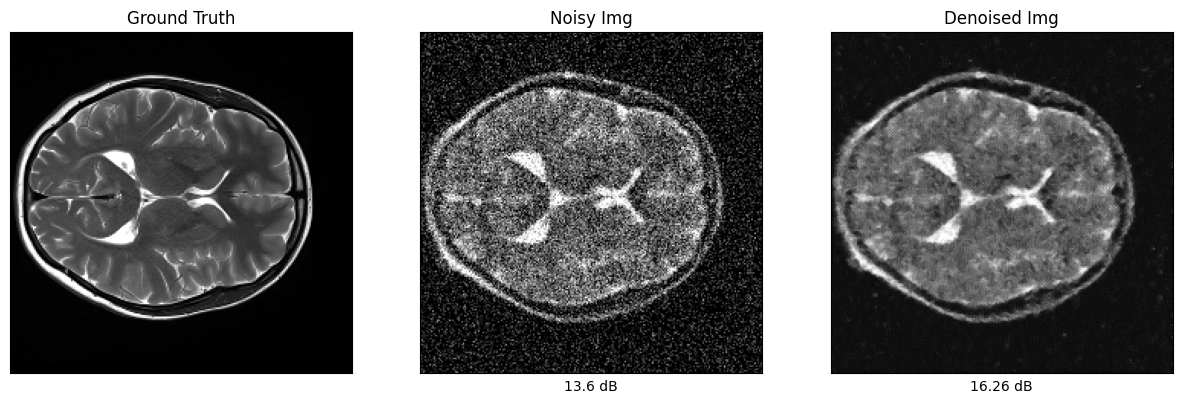

In [162]:
fig, ax = plt.subplots(1, 3,figsize=(15, 15))

ax[0].imshow(clean, cmap='gray')
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Ground Truth')

ax[1].imshow(noisy, cmap='gray')
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Noisy Img')
noisy_psnr = 10*np.log10(1/mse(noisy_img,clean_img).item())
ax[1].set(xlabel= str(round(noisy_psnr,2)) + ' dB')

ax[2].imshow(denoised, cmap='gray')
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Denoised Img')
ax[2].set(xlabel= str(round(PSNR,2)) + ' dB')

# Low-field MRI conditions

1. Load phantom understand its resolution and downsample it to the recommended resolution initially as (1, 1, 2 mm.)

2. Choose mid slice and apply to slice and remove noise.

3. Remove noise from the entire volume applying slice by slice.

4.

In [163]:
import nibabel as nib
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# Define the path to the Phantom_2.nii.gz file
phantom_path = '/content/DIY_MRI_Workshop_II_Recon/data/Training_data/Phantom_2.nii.gz'

# Load the NIfTI image for the phantom

phantom_nifti_img = nib.load(phantom_path)
phantom_volume_data = phantom_nifti_img.get_fdata()
phantom_header = phantom_nifti_img.header

print(f"Successfully loaded Phantom_2.nii.gz")
print(f"Phantom image dimensions (voxels): {phantom_volume_data.shape}")
print(f"Phantom voxel dimensions (resolution in mm): {phantom_header.get_zooms()}")


Successfully loaded Phantom_2.nii.gz
Phantom image dimensions (voxels): (110, 108, 16)
Phantom voxel dimensions (resolution in mm): (np.float32(2.0), np.float32(2.0370371), np.float32(10.0))


In [164]:
import numpy as np
import nibabel as nib
from scipy.ndimage import zoom

# Original data
data = phantom_nifti_img.get_fdata()

print("Original shape:", data.shape)
print("Original voxel size:",
      phantom_nifti_img.header.get_zooms()[:3])

# ---------------------------------------------------------
# Target voxel size
# ---------------------------------------------------------
target_voxel_size = np.array([1.0, 1.0, 1.0])

# Original voxel size
original_voxel_size = np.array(
    phantom_nifti_img.header.get_zooms()[:3]
)

# ---------------------------------------------------------
# Calculate scaling factor
# ---------------------------------------------------------
zoom_factor = original_voxel_size / target_voxel_size

print("Zoom factor:", zoom_factor)

# ---------------------------------------------------------
# Resample image data
# ---------------------------------------------------------
phantom_volume_data = zoom(
    data,
    zoom=zoom_factor,
    order=1
)

print("Original shape:", data.shape)
print("Resampled shape:", phantom_volume_data.shape)

Original shape: (110, 108, 16)
Original voxel size: (np.float32(2.0), np.float32(2.0370371), np.float32(10.0))
Zoom factor: [ 2.          2.03703713 10.        ]
Original shape: (110, 108, 16)
Resampled shape: (220, 220, 160)


In [165]:
# Select slice N
N = 80   # change this to any slice you want

slice_data = phantom_volume_data[:, :, N]

print("Selected slice:", N)
print("Slice shape:", slice_data.shape)
print("Slice min:", slice_data.min())
print("Slice max:", slice_data.max())
slice_min = slice_data.min()
slice_max = slice_data.max()

slice_norm = (
    slice_data - slice_min
) / (slice_max - slice_min)

print("Normalized range:",
      slice_norm.min(),
      slice_norm.max())

noisy_img = slice_norm

# tensor
noisy_img = torch.from_numpy(noisy_img).float().unsqueeze(0).unsqueeze(0)
noisy_img = noisy_img.to(device)

Selected slice: 80
Slice shape: (220, 220)
Slice min: 6.715213581558178
Slice max: 1901.5700594642549
Normalized range: 0.0 1.0


In [166]:
def pair_downsampler(img):
    #img has shape B C H W
    c = img.shape[1]

    filter1 = torch.FloatTensor([[[[0 ,0.5],[0.5, 0]]]]).to(img.device)
    filter1 = filter1.repeat(c,1, 1, 1)

    filter2 = torch.FloatTensor([[[[0.5 ,0],[0, 0.5]]]]).to(img.device)
    filter2 = filter2.repeat(c,1, 1, 1)

    output1 = F.conv2d(img, filter1, stride=2, groups=c)
    output2 = F.conv2d(img, filter2, stride=2, groups=c)

    return output1, output2

Display noisy image and its corresponding downsampled pair. Note how the downsampled images have half the spatial resolution.

Text(0.5, 1.0, 'Second downsampled')

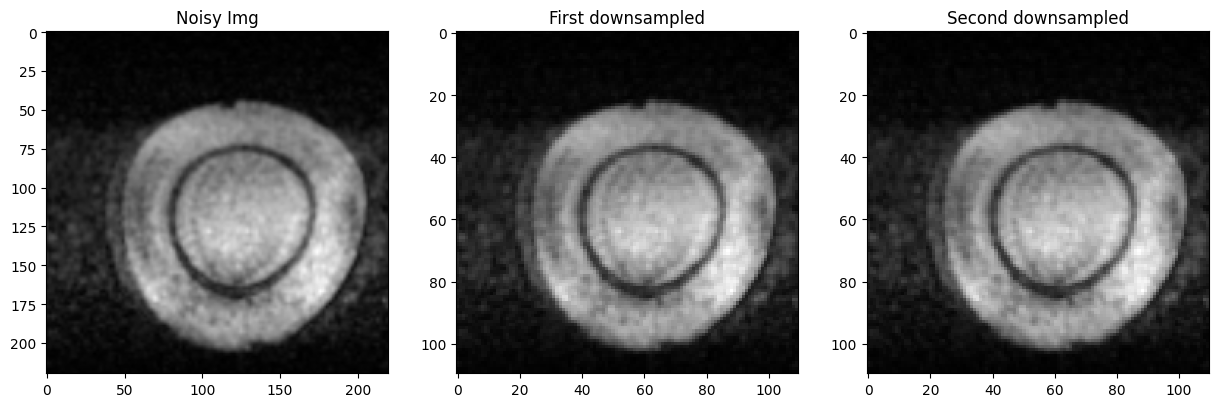

In [167]:
img1, img2 = pair_downsampler(noisy_img)

img0 = noisy_img.cpu().squeeze(0).permute(1,2,0)
img1 = img1.cpu().squeeze(0).permute(1,2,0)
img2 = img2.cpu().squeeze(0).permute(1,2,0)

fig, ax = plt.subplots(1, 3,figsize=(15, 15))

ax[0].imshow(img0,cmap='gray')
ax[0].set_title('Noisy Img')

ax[1].imshow(img1, cmap='gray')
ax[1].set_title('First downsampled')

ax[2].imshow(img2, cmap='gray')
ax[2].set_title('Second downsampled')

The number of parameters of the network is:  21313


  0%|          | 0/1000 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Denoised')

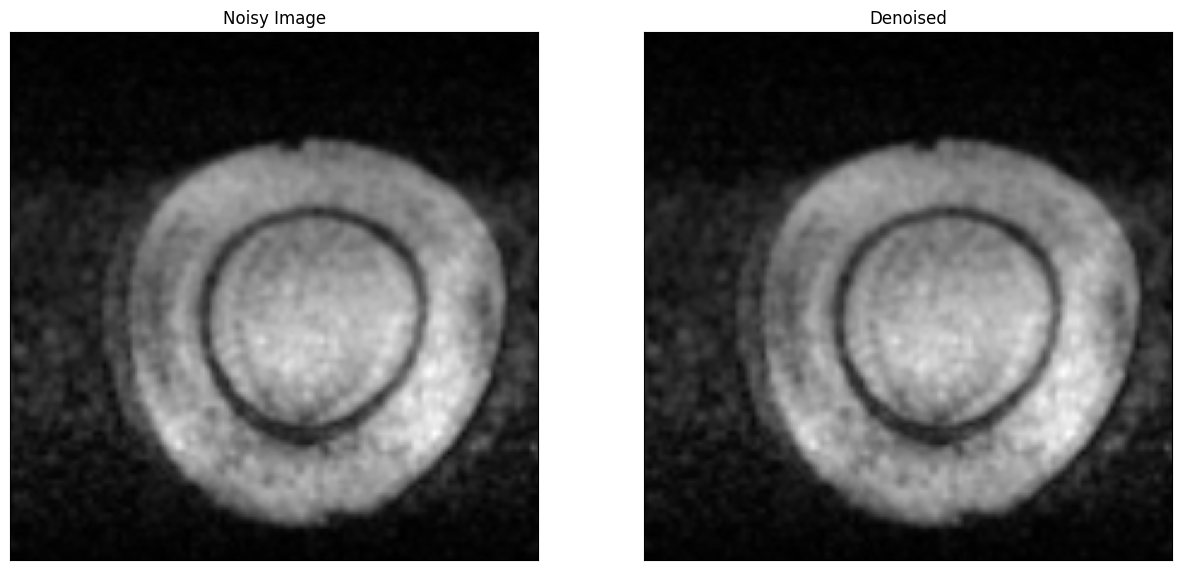

In [168]:
class network(nn.Module):
    def __init__(self,n_chan,chan_embed=48):
        super(network, self).__init__()

        self.act = nn.LeakyReLU(negative_slope=0.2, inplace=True)
        self.conv1 = nn.Conv2d(n_chan,chan_embed,3,padding=1)
        self.conv2 = nn.Conv2d(chan_embed, chan_embed, 3, padding = 1)
        self.conv3 = nn.Conv2d(chan_embed, n_chan, 1)

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.conv3(x)

        return x

n_chan = clean_img.shape[1]
model = network(n_chan)
model = model.to(device)
print("The number of parameters of the network is: ",  sum(p.numel() for p in model.parameters() if p.requires_grad))


max_epoch = 1000     # training epochs
lr = 0.01           # learning rate
step_size = 300     # number of epochs at which learning rate decays
gamma = 0.5          # factor by which learning rate decays

optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
for epoch in tqdm(range(max_epoch)):
    train(model, optimizer, noisy_img)
    scheduler.step()
denoised_img = denoise(model, noisy_img)

denoised = denoised_img.cpu().squeeze(0).permute(1,2,0)
# clean = clean_img.cpu().squeeze(0).permute(1,2,0)
noisy = noisy_img.cpu().squeeze(0).permute(1,2,0)
fig, ax = plt.subplots(1, 2,figsize=(15, 15))

ax[0].imshow(noisy, cmap='gray')
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Noisy Image')

ax[1].imshow(denoised, cmap='gray')
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Denoised')